# ___

# [ Machine Learning in Geosciences ]

## **ML Workflow exampl** 

*Author: lukas.brodsky@natur.cuni.cz*

@KAGIK

___


### 1.1 The Problem

TASK: Predict Forest Fires using Meteorological Data

Context: "Forest fires are a major environmental issue, creating economical and ecological damage while endangering human lives. Fast detection is a key element for controlling such phenomenon. To achieve this, one alternative is to use automatic tools based on local sensors, such as provided by meteorological stations. In effect, meteorological conditions (e.g. temperature, wind) are known to influence forest fires and several fire indexes, such as the forest Fire Weather Index (FWI), you can use such features, see below the figure for feature engineering. 
In this work, we explore a Machine Learning (ML) approach to **predict the burned area of forest fires**.


### 1.2 Assumptions

* The problem is a multivariate regression (will use multiple features to make a prediction); 
* There is no continuous flow of data, hence batch learning shall be applied; 
* The meterological data are good indicators of the forest fire; 
* There are enough variables (features) to predict the forest fire. 


### 1.3 Expected results 

* Machine Learning model to predict the burned area of the forest fires based on the meterological data. 
___    

### Weather features

<div>
<img src="attachment:image.png" width="600">
</div>

### Input data atrributes description

**Attribute information**

   1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
   2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
   3. month - month of the year: "jan" to "dec" 
   4. day - day of the week: "mon" to "sun"
   5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
   6. DMC - DMC index from the FWI system: 1.1 to 291.3 
   7. DC - DC index from the FWI system: 7.9 to 860.6 
   8. ISI - ISI index from the FWI system: 0.0 to 56.10
   9. temp - temperature in Celsius degrees: 2.2 to 33.30
   10. RH - relative humidity in %: 15.0 to 100
   11. wind - wind speed in km/h: 0.40 to 9.40 
   12. rain - outside rain in mm/m2 : 0.0 to 6.4 
   13. area - the burned area of the forest (in ha): 0.00 to 1090.84 


#####  Problem definition checklist

    [] What exactly is the target variable y? Forest fire T/F
    [] What are the input features X? 
    [] Is this classification, regression, or another task?  Regresion or prediction 
    [] What is the unit of observation (pixel, polygon, time step)? time step
    [] Is this prediction or explanation? prediction more
    [] What assumptions am I making about the process?
    [?] What would a “good” prediction mean in this context? 
    [avoid] Is there spatial or temporal structure I must consider?


In [43]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
print(3)

3


In [44]:
# Input data 
url = 'data/forestfires.csv'
dataGEO = gpd.read_file(url)
data2 = pd.read_csv(url)

dataGEOshow = gpd.read_file(url).head()
dataGEOshow

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0
3,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0,0


### 2. Exploratory Data Analysis (EDA) 

<Axes: >

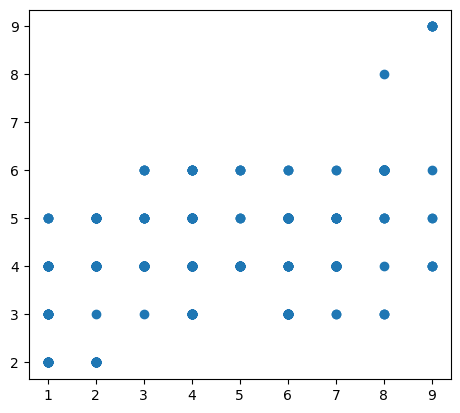

In [45]:
# plot burnd area - spatial plot

from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(dataGEO["X"], dataGEO["Y"])]

gdf = gpd.GeoDataFrame(dataGEO, geometry=geometry)

gdf.plot()


In [46]:
# hist burned area 

fires = data2["area"]
fires.head




<bound method NDFrame.head of 0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
512     6.44
513    54.29
514    11.16
515     0.00
516     0.00
Name: area, Length: 517, dtype: float64>

In [47]:
biggest = data2["area"].sort_values(ascending=True)
biggest

0         0.00
1         0.00
2         0.00
3         0.00
4         0.00
        ...   
236     200.94
237     212.88
479     278.53
415     746.28
238    1090.84
Name: area, Length: 517, dtype: float64

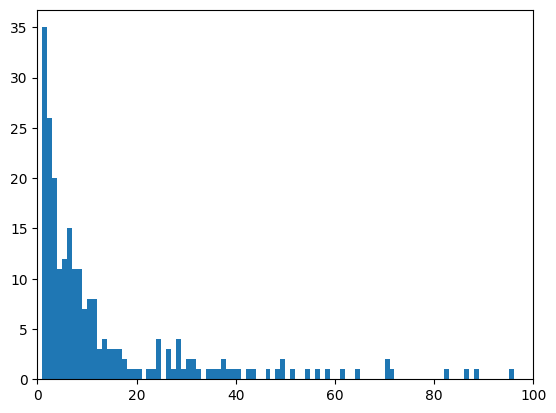

In [48]:
plt.hist(fires,bins=range(1, 500))
plt.xlim(0,100)
plt.show()


In [ ]:
# hist meteo data 


In [49]:
df_sel = data2

data2.head

<bound method NDFrame.head of      X  Y month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain   area
0    7  5   mar  fri  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.00
1    7  4   oct  tue  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.00
2    7  4   oct  sat  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.00
3    8  6   mar  fri  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.00
4    8  6   mar  sun  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.00
..  .. ..   ...  ...   ...    ...    ...   ...   ...  ..   ...   ...    ...
512  4  3   aug  sun  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0   6.44
513  2  4   aug  sun  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0  54.29
514  7  4   aug  sun  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0  11.16
515  1  4   aug  sat  94.4  146.0  614.7  11.3  25.6  42   4.0   0.0   0.00
516  6  3   nov  tue  79.5    3.0  106.7   1.1  11.8  31   4.5   0.0   0.00

[517 rows x 13 columns]>

In [ ]:
# coreletion betwen features 
# FROM LECTION
# df_sel = data2
# df_sel = df_sel.drop(['month'],inplace = True,axis=1)
# df_sel = df_sel.drop(['day'],inplace = True,axis=1) # not working 


In [50]:

cmap = sns.diverging_palette(230, 20, as_cmap=True) # like this 


In [51]:
df_sel.drop(['month'], inplace=True, axis=1)
df_sel.drop(['day'], inplace=True, axis=1)

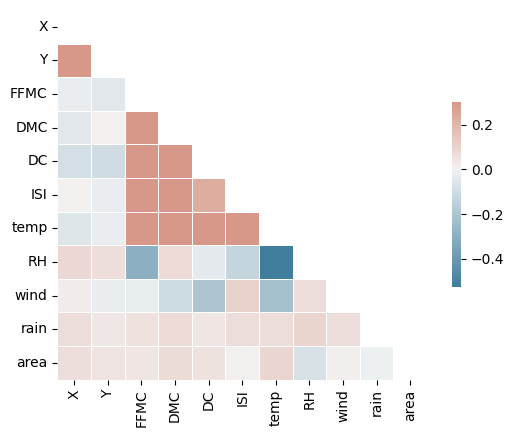

In [52]:
corr = df_sel.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.show()

In [ ]:
# explore sun sat days  vs fires ???

# no any significantly 

##### EDA checklist 

    [x] What is the distribution of each feature?
    [no] Are there missing values? How many?
    [no] Are there outliers or unrealistic values?
    [no but log] Is the dataset balanced (for regresion)?  SMOGER
    [] Are features correlated or redundant?
    [] Are there different regimes or clusters in the data?
    [x] Does the data reflect real-world variability?
    [avoid] Are there spatial or temporal patterns?


### 3. Data preparation 

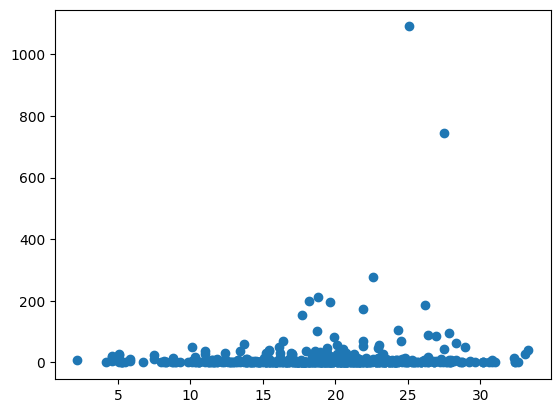

In [53]:
# FROM LECTION 
plt.scatter(data2['temp'],data2['area'])

In [ ]:
# without AI
num_df = data2

num_df["is_fire"] = (num_df["area"] > 0).astype(int)

print(num_df["is_fire"].value_counts())

is_fire
1    270
0    247
Name: count, dtype: int64


In [57]:
num_df.head

<bound method NDFrame.head of      X  Y  FFMC    DMC     DC   ISI  temp  RH  wind  rain   area  is_fire
0    7  5  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.00        0
1    7  4  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.00        0
2    7  4  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.00        0
3    8  6  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.00        0
4    8  6  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.00        0
..  .. ..   ...    ...    ...   ...   ...  ..   ...   ...    ...      ...
512  4  3  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0   6.44        1
513  2  4  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0  54.29        1
514  7  4  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0  11.16        1
515  1  4  94.4  146.0  614.7  11.3  25.6  42   4.0   0.0   0.00        0
516  6  3  79.5    3.0  106.7   1.1  11.8  31   4.5   0.0   0.00        0

[517 rows x 12 columns]>

In [58]:
# without AI

X = num_df.drop(columns=["area"])
X['log_area']

KeyError: "['day'] not found in axis"

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

In [29]:
model.fit(X_train,y_train)

NameError: name 'model' is not defined

In [30]:
# without AI

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [31]:
####### WITH AI #######
# Convert categorical strings into dummy variables
data_final = data2
# Define X and y 
X = data_final.drop(['area'], axis=1) # Drop the raw area
y = np.log1p(data_final['area'])      # Use the log transformed target

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Initialize and train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

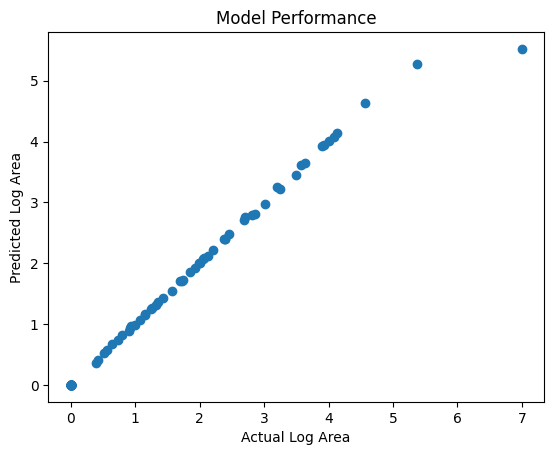

Mean Absolute Error: 0.023426970676568147


In [34]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Log Area")
plt.ylabel("Predicted Log Area")
plt.title("Model Performance")
plt.show()

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions)}")

In [35]:
data_encoded

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,0.000000
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,0.000000
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,0.000000
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,0.000000
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,2.006871
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,4.012592
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,2.498152
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,0.000000


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data2['log_area'] = np.log1p(data2['area'])

data_encoded = data2

X = data_encoded.drop(['area','log_area','ISI' ,'X','Y' ], axis=1) #  'RH',
y = data_encoded['log_area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
y_train_pred = model.predict(X_train)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- ISI
- X
- Y
- log_area


In [ ]:
model

In [ ]:
# mad_train = MAD(y_train, y_train_pred)

In [ ]:
# car values to numerical

In [ ]:
# split: stratified must!

In [ ]:
# scale!

#####  Data Preparation chacklist

    [no] Did I split the data before preprocessing?
    [no] Is there any data leakage (future info, target leakage)?
    [] Are features scaled/normalized appropriately?
    [] How are missing values handled?
    [ignored] Are categorical variables encoded correctly?
    [no] Did I remove irrelevant or redundant features?
    [] Is class imbalance addressed (if needed)?
    [] Is preprocessing reproducible (pipeline)?


    # it is regresion modell!! 


### 4. Select and train model 

In [ ]:
# my atempt 

from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()

In [ ]:
CV =3 

In [ ]:
params = {'n_estimators':[50,100,200,3000],
          'max_depth':[1,10,20,100]}

In [ ]:
gsff = GridSearchCV(model,params,cv=CV,n_jobs=-1)

In [ ]:
gsff

In [ ]:
y_train

In [ ]:
gsff.fit(X_train, y_train)

In [ ]:
model = RandomForestRegressor(max_depth=20,n_estimators=200,random_state=42)

In [ ]:
model.fit(X_train,y_train)

In [ ]:
y_train_pred = model.predict(X_train)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

print("TRAIN MAE:", mae_train)
print("TRAIN RMSE:", rmse_train)
print("TRAIN R2:", r2_train)

In [ ]:
# predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=== TRAIN ===")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))

In [ ]:
# WAS ON LECTION 
from sklearn.ensemble import RandomForestRegressor


In [ ]:
# WAS ON LECTION 

df_sel = data2.corr()

In [ ]:
def MAD(y,y_hat):
    return (1/y.size) * (np.sum(np.abs(y-y_hat)))

In [ ]:
X = df_sel.copy()
X=X.drop(['area',area_ln],axis=1)

In [ ]:
# non linear problem BUT i will start with simple multi-variete linear model as baseline 

In [ ]:

X = num_df.drop(columns=["area", "log_area", "is_fire"]) 
y = num_df["area"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

models = {
    "Linear Regression": LinearRegression(),
    "SVR (SVM)": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)
    log_pred = model.predict(X_test_scaled)
    
    mae_log = mean_absolute_error(y_test_log, log_pred)
    
    real_pred = np.expm1(log_pred)
    mae_ha = mean_absolute_error(y_test, real_pred)
    
    print(f"--- {name} ---")
    print(f"MAE (log scale): {mae_log:.4f}")
    print(f"MAE (in ha): {mae_ha:.2f} ha")

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)
    log_pred = model.predict(X_test_scaled)
    
    real_pred = np.expm1(log_pred)
    
    mae = mean_absolute_error(y_test, real_pred)
    mse = mean_squared_error(y_test, real_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, real_pred)
    
    print(f"--- {name} ---")
    print(f"MAE: {mae:.2f} ha")
    print(f"RMSE: {rmse:.2f} ha")
    print(f"R^2 Score: {r2:.4f}")
    print("-" * 20)

In [ ]:
pass

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear": LinearRegression(),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Iterate and evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"{name} MAE: {mean_absolute_error(y_test, preds):.4f}")

#####  Data Preparation checklist

    [nonlinear, difficult, step-wise continuos, ensemble] What assumption does this model make?
    [ok] Does the data satisfy this assumption?
    [no] Is the model too simple (underfitting risk)?
    [-] Is the model too complex (overfitting risk)?
    [RF is robust] How sensitive is the model to noise?
    [avoid] Does the model handle spatial/temporal structure?
    [yes] Is the model interpretable if needed?
    [one] Am I comparing multiple models or guessing one?


### 5. Model fine-tuning & validation 

In [ ]:
# ON lection 


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# SVR Space
svr_params = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# RF Space
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Define the parameter grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# 2. Initialize the Base Model
rf = RandomForestRegressor(random_state=42)

# 3. Setup RandomizedSearch
# We use 5-fold CV as you noted in your checklist
n_iter_search = 20 
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=n_iter_search, cv=5, 
                                   scoring='neg_mean_absolute_error',
                                   random_state=42)

# 4. Fit the model
random_search.fit(X_train_scaled, y_train)

# 5. DEFINE 'best_rf'
best_rf = random_search.best_estimator_

print("Best Parameters found:", random_search.best_params_)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get importances
importances = best_rf.feature_importances_
# Use the column names from your encoded dataframe
feature_names = X.columns 

# Sort them
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Best Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
residuals = y_test - best_rf.predict(X_test_scaled)
plt.hist(residuals, bins=20)
plt.title("Error Distribution (Residuals)")
plt.show()

In [ ]:
# RandomizeSearch on limited models a/ SVR and B/ RF 

In [ ]:
# Cross calidation  folds: 5-10 (up to laptop)

In [ ]:
# sensitivity through splits (CV??)

In [ ]:
# MAE

###### Model-finetuning & validation checklist

    [] Is my validation strategy appropriate (CV, spatial CV)?
    [Yes] Is the test set truly unseen?
    [kind of] Am I tuning hyperparameters on validation (not test)?
    [] Are results stable across different splits?
    [] What metric am I optimizing?
    [] Does the metric reflect the real objective?
    [] Am I overfitting during tuning?
    [] Is model performance consistent?


### 6. Results interpretation


In [ ]:
pass 

In [ ]:
pass

In [ ]:
pass 

##### Results interpretation checklist

    [generalized enough] How good is the model? (metrics)
    [higher area higher reseduals] Where does it fail? (error structure)
    [NA] Why does it fail? (bias/variance, data)
    [ok] Does it make sense scientifically?
    [I belive yes ] Can we trust it in real-world use? 


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Загрузка данных
url = 'data/forestfires.csv'
data = pd.read_csv(url)

# Фильтрация: оставляем только летние месяцы
summer_months = ['jun', 'jul', 'aug', 'sep']
data_summer = data[data['month'].isin(summer_months)].copy()

print(f"Записей за лето: {len(data_summer)}")

Записей за лето: 405


In [39]:
# Удаляем ненужные для базовой модели колонки или кодируем их
# Для простоты в этом примере преобразуем категориальные данные в dummy-переменные
df_prepared = pd.get_dummies(data_summer, columns=['month', 'day'])

# Определяем целевую переменную и признаки
X = df_prepared.drop(['area'], axis=1)
y = df_prepared['area']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Инициализация регрессора
model = RandomForestRegressor(random_state=42)

# Сетка параметров
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Поиск лучших параметров
grid_search = GridSearchCV(model, params, cv=3, n_jobs=-1, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")

Лучшие параметры: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


MAE: 19.40
RMSE: 41.89
R2 Score: -0.23


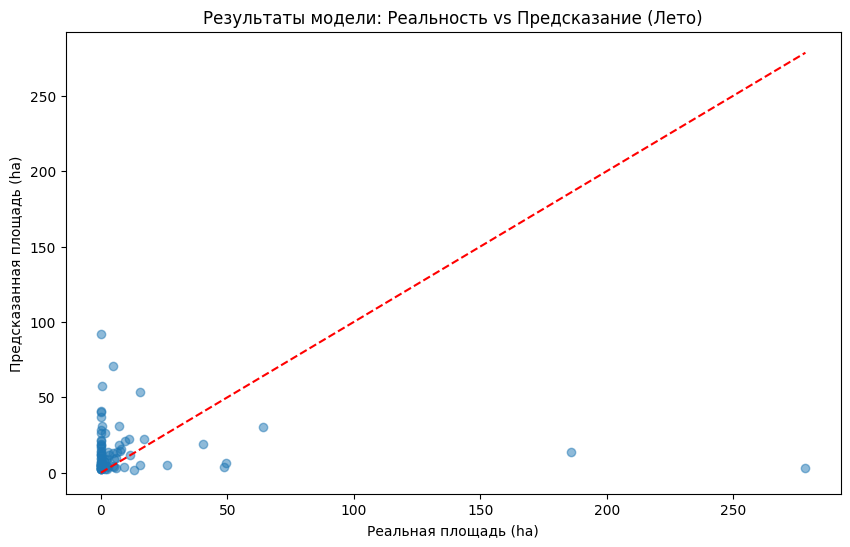

In [41]:
# Предсказание
y_pred = best_model.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Визуализация: Факт vs Прогноз
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальная площадь (ha)')
plt.ylabel('Предсказанная площадь (ha)')
plt.title('Результаты модели: Реальность vs Предсказание (Лето)')
plt.show()